In [1]:
import torch
import CT.Models.misc as misc
import CT.Inference.Kolmogorov.performance as performance
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CT_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20251213_225527-d0htlgni/files/checkpoint_last.p"
CT = misc.load_diffusion_model(CT_file_path).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [2]:
CT.config

{'model_type': 'ModernUnetRegressor',
 'input_channels': 3,
 'output_channels': 1,
 'hidden_channels': 64,
 'norm': False,
 'dim_mults': [2, 2, 2],
 'n_blocks': 2,
 'mid_attn': False,
 'is_attn': (False, False, False, False),
 'activation': 'gelu',
 'image_width': 64,
 'image_height': 64,
 'first_embedding_dim': 512,
 'noise_short_lag': True,
 'different_noise': True,
 'fix_short_lag': 1,
 'second_embedding_dim': 512,
 'third_embedding_dim': None,
 'save_path': '/scratch/ql2221/CT_models/wandb_data/wandb/run-20251213_225527-d0htlgni/files',
 'save_name': 'model_weights.pt',
 'diffusion_steps': 1000,
 'regression_output_dim': 1000,
 'lagsteps': 100,
 'project': 'CT',
 'wandb_run_name': '12/12_diffnoise_short_lag',
 'wandb_log_freq': 100,
 'ddp': False,
 'PDE': 'Kolmogorov',
 'file_path': '/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/5_Emulator_step_size_training_data.p',
 'subsample': None,
 'train_ratio': 0.95,
 'loader_workers': 0,
 'regression_loss_weight': 1,
 'optimization'

In [3]:
#load data
data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p")
data = data_dict["data"]
print(data.shape)

/state/partition1/job-356883/ipykernel_2327685/1127623401.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flo

torch.Size([5, 50000, 64, 64])


In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import trange   # tqdm with notebook/terminal auto-detection


def compute_predicted_distribution(
    CT,
    classifier_test_data,
    device,
    short_lag=2,
    long_lag=80,
    show_plot=True,
    use_tqdm=True,
):
    """
    Computes the (true_noise_level x predicted_noise_level) distribution
    for a diffusion model classifier.

    Returns:
        predicted_distribution: torch.Tensor of shape
            (diffusion_steps, diffusion_steps)
    """
    softmax = nn.Softmax(dim=1)
    diffusion_steps = CT.config["diffusion_steps"]

    predicted_distribution = torch.zeros(
        (diffusion_steps, diffusion_steps),
        dtype=torch.float32
    )

    x = classifier_test_data.to(device)

    # Keep scalar lags separate so they don't get overwritten
    scalar_short_lag = short_lag
    scalar_long_lag = long_lag

    with torch.no_grad():
        iterator = trange(
            diffusion_steps,
            desc="Computing predicted distribution",
            disable=not use_tqdm,
        )

        for aa in iterator:
            # Current timestep slice
            x_t = x[:, -1:]  # last frame / step

            # Short- and long-lag slices
            x_t_short_lag = x[:, -scalar_short_lag - 1:-scalar_short_lag, :, :]
            x_t_long_lag = x[:, -scalar_long_lag - 1:-scalar_long_lag, :, :]

            # Forward diffuse current x_t
            noise = torch.randn_like(x_t, device=device)
            noise_categories = torch.full(
                (x_t.shape[0],),
                aa,
                dtype=torch.int64,
                device=device
            )
            x_t_noised = CT._forward_diffusion(x_t, noise_categories, noise)

            # Lag indices as tensors for the model
            short_lag_tensor = torch.full(
                (x_t_noised.shape[0],),
                scalar_short_lag,
                dtype=torch.int64,
                device=device
            )
            long_lag_tensor = torch.full(
                (x.shape[0],),
                scalar_long_lag,
                dtype=torch.int64,
                device=device
            )

            # Optionally diffuse short-lag frame
            if CT.config.get("noise_short_lag") is True:
                if CT.config["different_noise"] is False:
                    x_t_short_lag = CT._forward_diffusion(
                        x_t_short_lag, noise_categories, noise
                    )
                else:
                    noise_prime = torch.randn_like(x_t, device=device)
                    x_t_short_lag = CT._forward_diffusion(
                        x_t_short_lag, noise_categories, noise_prime
                    )

            # Concatenate inputs for the classifier
            noised_imgs = torch.cat(
                (x_t_noised, x_t_short_lag, x_t_long_lag),
                dim=1
            )

            # Predict noise level
            _, pred_noise_level = CT.model(
                noised_imgs,
                first=short_lag_tensor,
                second=long_lag_tensor,
                third=None,
                regression_output=True
            )

            # Average over batch and store row for true noise level = aa
            predicted_distribution[aa] = softmax(pred_noise_level).mean(dim=0).cpu()

    if show_plot:
        fig = plt.figure()
        plt.imshow(predicted_distribution)
        plt.colorbar()
        plt.xlabel("Predicted noise level")
        plt.ylabel("True noise level")
        plt.tight_layout()
        plt.show()

    return predicted_distribution


/ext3/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import torch

# x: [5, 5000, 64, 64]
data = data[:,::10]/4.44
# 1. Split along dim=1 into 50 chunks of size 100
chunks = data.split(100, dim=1)  # tuple of 50 tensors, each [5,100,64,64]

# 2. Now split batch dimension so each chunk becomes 5 separate tensors
#    producing 250 tensors of shape [1,100,64,64]
chunks = [c[i:i+1] for c in chunks for i in range(c.size(0))]

# 3. Concatenate along the first dimension
out = torch.cat(chunks, dim=0)

print(out.shape)   # [250, 100, 64, 64]

torch.Size([250, 100, 64, 64])


Computing predicted distribution: 100%|██████████| 1000/1000 [00:09<00:00, 105.30it/s]


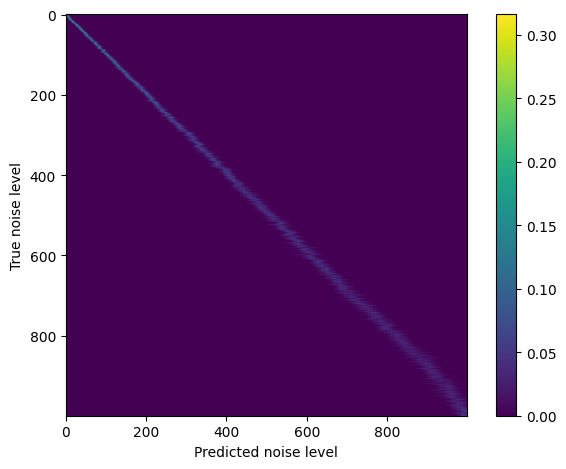

In [6]:
# classifier_test_data = data[:500,:100]
predicted_distribution = compute_predicted_distribution(
    CT,
    out[0:1],
    device,
    short_lag=1,
    long_lag=80,
    show_plot=True,
    use_tqdm=True,
)

In [18]:
x = data[0:1].to(device)

#getting x_t and noise it
x_t = x[:,-1:]
noise = torch.randn_like(x[:,-1:]).to(device)
s = torch.tensor([100]).to(device)
x_t_noised = CT._forward_diffusion(x_t, s, noise).to(device)

In [19]:
short_lag = torch.tensor([1]).to(device)
long_lag = torch.tensor([99]).to(device)
x_t_short_lag = x[:,-(short_lag)-1:-(short_lag)].to(device)
if CT.config.get("noise_short_lag") is True:
    if CT.config["different_noise"] is False:
        x_t_short_lag = CT._forward_diffusion(
            x_t_short_lag, s, noise
        )
    else:
        print(1)
        noise_prime = torch.randn_like(x_t, device=device)
        x_t_short_lag = CT._forward_diffusion(
            x_t_short_lag, s, noise_prime
        )

x_t_minus_long_lag = x[:,-(long_lag)-1:-(long_lag)].to(device)
x_conditional = torch.cat((x_t_noised, x_t_short_lag, x_t_minus_long_lag), dim=1).to(device)

x_denoised = CT.denoising(x_conditional, short_lag, long_lag, s)

1


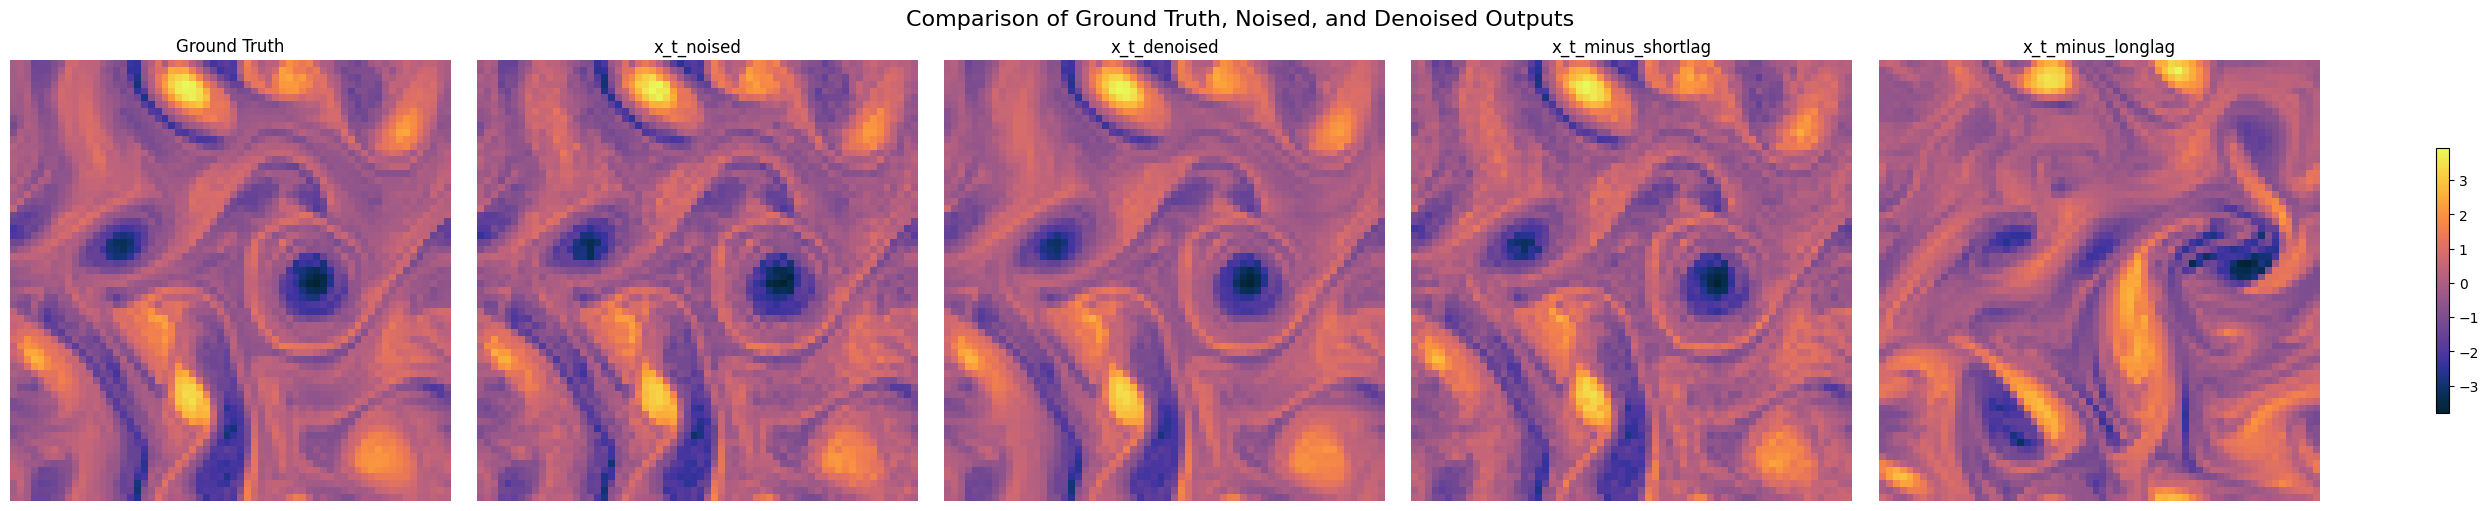

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x_t,                
    x_t_noised,
    x_denoised,
    x_t_short_lag,
    x_t_minus_long_lag
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()
